In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm, expm_multiply
from numpy.linalg import eigh
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from sympy import Matrix
import cvxpy as cp
import random

import h5py

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [3]:
# PARAMETERS

# Lattice geometry
X = 32
Y = 34


# Number of edges
Ex = Y*(X-1)
Ey = X*(Y-1)
R = Ex + Ey

# Number of modes
M = X*Y
M_occ = (M-X)//2

# Hamiltonian engineering
N = 3**M # Total number of pulses
ratio = 6 # Column to row ratio
K = ratio*R # Number of pulses (columns) to be considered

In [4]:
# FUNCTIONS

def site_to_index(x,y):
    if x >= X or y >= Y:
        print('x needs to be less than ', X, ' and, y needs to be less than', Y)
    else:
        return x + X*(y)

def index_to_site(m):
    x = m % X
    y = m // X
    return (x,y)


def square_lattice_edge_vertex_incidence(Lx: int, Ly: int, *, periodic: bool = False) -> np.ndarray:
    """
    Build an (E x V) array M for an Lx-by-Ly square lattice.

    Columns = vertices, indexed by v = x + Lx*y.
    Rows    = undirected edges (each nearest-neighbor bond listed once).

    For each edge-row e = (u, v):
        M[e, u] = 1
        M[e, v] = 2
        all other entries 0.

    If periodic=False: open boundary conditions.
    If periodic=True : wrap-around in both x and y directions.
    """
    if Lx <= 0 or Ly <= 0:
        raise ValueError("Lx and Ly must be positive integers.")

    def vid(x: int, y: int) -> int:
        return x + Lx * y

    edges = []

    # Horizontal edges: (x,y) -- (x+1,y)
    for y in range(Ly):
        for x in range(Lx):
            x2 = (x + 1) % Lx
            if (not periodic) and (x + 1 >= Lx):
                continue
            u = vid(x, y)
            v = vid(x2, y)
            edges.append((u, v))

    # Vertical edges: (x,y) -- (x,y+1)
    for y in range(Ly):
        for x in range(Lx):
            y2 = (y + 1) % Ly
            if (not periodic) and (y + 1 >= Ly):
                continue
            u = vid(x, y)
            v = vid(x, y2)
            edges.append((u, v))

    V = Lx * Ly
    E = len(edges)
    M = np.zeros((E, V), dtype=np.int8)

    # Put 1 on the first endpoint, 2 on the second endpoint
    for e, (u, v) in enumerate(edges):
        if u == v:
            raise RuntimeError("Self-edge encountered (should not happen for square lattice).")
        M[e, u] = 1
        M[e, v] = 2

    return M

#------------------------------------------------------------------------------------------------
# Function which takes a number between 0 and N-1 and converts it to a base 3 array

def tritarray(x,M):
    tritarray = np.zeros(shape = M)
    for j in range(M):
        r = x % 3
        x = x // 3 
        tritarray[-(j+1)] = r
    return tritarray

#------------------------------------------------------------------------------------------------
# Function for selecting K random pulses on M modes

def random_pulses(M,K):
    
    N = 3**M
    
    sample = random.sample(range(N),K) 
    pulses = np.zeros(shape = (K,M)) # K pulses of length M
    
    for j in range(K):
        pulses[j] = tritarray(sample[j],M)
        
    return pulses
#------------------------------------------------------------------------------------------------
# Function for selecting K random pulses on M modes efficiently (with replacement)

def random_pulses_eff(M, K, rng=None):
    """K uniformly random tritstrings of length M, entries in {0, 1, 2}."""
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0, 3, size=(K, M), dtype=np.int8)
#------------------------------------------------------------------------------------------------

# Check if F is feasible
def check_feasible(F):

    x = cp.Variable(F.shape[1])
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == 0, x >= 1]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    LP_has_solution = 0
    F_has_full_rank = 0
    
    if type(x.value) == np.ndarray:
        LP_has_solution = 1
    if F.shape[0]- np.linalg.matrix_rank(F)==0:
        F_has_full_rank = 1
    feasible = LP_has_solution * F_has_full_rank
    
    return bool(feasible)

#------------------------------------------------------------------------------------------------
# Function for finding the constraint matrix with given pulses

def constraint_matrix_given_pulses(R,K,rows,pulses):

    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = rows[i]@pulses[j]
            F[i][j] = w**power

    return F
#------------------------------------------------------------------------------------------------
# Hamiltonian Engineering
def hamiltonian_engineering(R,K,rows,pulses,beta):

    F = constraint_matrix_given_pulses(R,K,rows,pulses)
    
    # print(check_feasible(F))

    x = cp.Variable(K)
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == beta, x>=0]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    return problem.value, x.value, check_feasible(F)

#------------------------------------------------------------------------------------------------
# Function for adding the conjugate components to the coefficient vector
def conjugate_components(vec,number_x_edges,number_y_edges):
    number_edges = number_x_edges + number_y_edges
    vec2 = np.zeros(2*number_edges, dtype=complex)
    for i in range(number_x_edges):
        vec2[i] = vec[i]
        vec2[i+number_x_edges] = vec[i].conj()
    for j  in range (number_y_edges):
        vec2[j + 2*number_x_edges] = vec[j+number_x_edges]
        vec2[j+2*number_x_edges+number_y_edges] = vec[j+number_x_edges].conj()
        
    return vec2

#------------------------------------------------------------------------------------------------
def edge_indices(Lx=X,Ly=X):

    num_x_edges = Y*(X-1)
    num_y_edges = X*(Y-1)
    num_edges = num_x_edges + num_y_edges
    
    row_ind = np.zeros(2*num_edges, dtype=int)
    col_ind = np.zeros(2*num_edges, dtype=int)

    e=0
    
    # X edges
    for y in range(Y):    
        for x in range(X-1):
            j = site_to_index(x,y)
            k = site_to_index(x+1,y)
            row_ind[e] = j
            col_ind[e] = k
            e += 1
            
    # X edges transposed
    for y in range(Y):    
        for x in range(X-1):
            j = site_to_index(x,y)
            k = site_to_index(x+1,y)
            row_ind[e] = k
            col_ind[e] = j
            e += 1
            
    # Y edges
    for y in range(Y-1):    
        for x in range(X):
            j = site_to_index(x,y)
            k = site_to_index(x,y+1)
            row_ind[e] = j
            col_ind[e] = k
            e += 1
    # Y edges transposed
    for y in range(Y-1):    
        for x in range(X):
            j = site_to_index(x,y)
            k = site_to_index(x,y+1)
            row_ind[e] = k
            col_ind[e] = j
            e += 1
            
    return row_ind,col_ind

#------------------------------------------------------------------------------------------------
# Function for finding the ground state of a quadratic Hamiltonian (written by Claude, understand better)
from scipy.sparse.linalg import eigsh

def ground_state_rdm(h, M, force_dense=False):
    """
    1-RDM of the M-particle ground state of H = sum_{ij} h_{ij} c_i^† c_j.

    Convention: rho_{ij} = <c_j^† c_i> = (Phi Phi^†)_{ij}.

    Parameters
    ----------
    h : (N, N) Hermitian, dense or sparse
    M : int, particle number
    force_dense : if True, always use np.linalg.eigh

    Returns
    -------
    Phi  : (N, M) complex, columns = occupied orbitals (orthonormal)
    rho  : (N, N) complex Hermitian, rank-M projector
    eps  : (M,) sorted single-particle energies of occupied orbitals
    E_gs : float, ground-state energy = sum(eps)
    """
    N = h.shape[0]
    use_sparse = sp.issparse(h) and (M < (N+2) // 2) and not force_dense
    if use_sparse:
        print('Using sparse')
        eps, Phi = eigsh(h, k=M, which='SA')
        order = np.argsort(eps)
        eps, Phi = eps[order], Phi[:, order]
    else:
        h_dense = h.toarray() if sp.issparse(h) else h
        all_eps, U = np.linalg.eigh(h_dense)
        eps = all_eps[:M]
        Phi = U[:, :M]
    rho  = np.array(Phi @ Phi.conj().T)
    E_gs = float(eps.sum())
    return Phi, rho, eps, E_gs

#------------------------------------------------------------------------------------------------
#  Function for extracting the nonzero pulses and evolution times from the output of the LP
def nonzero_pulses(pulses,times, M=M):
    
    rounded_times = np.round(times,5)
    nonzero_times = rounded_times[ rounded_times != 0]
    nonzero_indices = np.nonzero(rounded_times)[0]
    nonzero_pulses = np.zeros((len(nonzero_indices),M))
    for k in range(len(nonzero_indices)):
        nonzero_pulses[k] = pulses[nonzero_indices[k]]
    return nonzero_pulses,nonzero_times

In [5]:
row_ind,col_ind = edge_indices(X,Y)
matrix_ind = (row_ind,col_ind)

In [6]:
# System Hamiltonian coefficients

# Homogeneous tunnelling coefficients
t = 1

# coefficient vector with conjugate termsc
alpha2 = np.zeros(2*R)

for e in range(2*R):
    alpha2[e] = t
    
# System Hamiltonian

h_system_csr = sp.csr_matrix((alpha2,(row_ind,col_ind)))
h_system_csc = h_system_csr.tocsc()

(h_system_csr - h_system_csr.conj().T).nnz == 0

True

In [7]:
# Target Hamiltonian (Harper-Hofstadter)

flux = 1/3
phase = np.exp(1j*2*np.pi*flux)
# beta_HH = np.array([1,1,phase,phase,phase**2,phase**2,phase**3,phase**3,1,1,1,1,1,1,1,1,1]) #3x4
# beta_HH2 = conjugate_components(beta_HH,Ex,Ey)


# Target Hamiltonian coefficients
beta_HH = np.zeros(R,dtype=complex)
e = 0

# X edges
for y in range(Y):
    for x in range(X-1):
        m = y % 3
        beta_HH[e] = phase**(m)
        e += 1

# Y edges
for y in range(Y-1):
    for x in range(X):
        beta_HH[e] = 1
        e += 1
beta_HH2 = conjugate_components(beta_HH,Ex,Ey)

h_HH_csr = sp.csr_matrix((beta_HH2,(row_ind,col_ind)))
h_HH_csc = sp.csc_matrix((beta_HH2,(row_ind,col_ind)))

(h_HH_csr - h_HH_csr.conj().T).nnz == 0

True

In [8]:
# Bond current operator 

def bond_current(x1,y1,x2,y2,gamma, h = h_HH_csr):
    j = site_to_index(x1,y1)
    k = site_to_index(x2,y2)
    J = 2*(h[j,k]*gamma[k,j]).imag
    
    return J
# Loop current operator

def loop_current(x,y,gamma, h=h_HH_csr):
    if x >= X-1 or y >= Y-1:
        print('x needs to be away from the right boundary, and y needs to be away from the top boundary')
    else:
        loop = bond_current(x,y,x+1,y,gamma)+bond_current(x+1,y,x+1,y+1,gamma)+bond_current(x+1,y+1,x,y+1,gamma)+bond_current(x,y+1,x,y,gamma)
        
        return loop
    
# Bottom Edge current
def bottom_edge_current(gamma,h=h_HH_csr):
    current = 0
    for x in range(X-1):
        current += bond_current(x,0,x+1,0,gamma, h=h)
    return current
# Top Edge current
def top_edge_current(gamma,h=h_HH_csr):
    current = 0
    for x in range(X-1):
        current += bond_current(x,Y-1,x+1,Y-1,gamma, h=h)
    return current

# Left Edge current
def left_edge_current(gamma,h=h_HH_csr):
    current = 0
    for y in range(Y-1):
        current += bond_current(0,y,0,y+1,gamma, h=h)
    return current
# Right Edge current
def right_edge_current(gamma,h=h_HH_csr):
    current = 0
    for y in range(Y-1):
        current += bond_current(X-1,y,X-1,y+1,gamma, h=h)
    return current

In [9]:
with h5py.File("slater_matrices_1088.hdf5", "r") as slater_file:
    slater_matrices_eng = slater_file["slater_matrices_eng"][...]
    slater_matrices_exact = slater_file["slater_matrices_exact"] [...]
    trotter_steps = slater_file["trotter_steps"] [...]
    time_steps_eng = slater_file["time_steps"][...]
    time_steps_exact = slater_file["time_steps_exact"][...]
    matching_indices = slater_file["matching_indices"][...]

    slater_file.close()

In [10]:
slater_matrices_exact.shape

(1000, 1088, 528)

In [11]:
slater_matrices_eng.shape

(10, 7, 1088, 528)

In [12]:
trotter_steps[9]

np.int64(2200)

In [13]:
Left_eng = np.zeros(len(time_steps_eng))
Right_eng = np.zeros(len(time_steps_eng))
Top_eng = np.zeros(len(time_steps_eng))
Bot_eng = np.zeros(len(time_steps_eng))

for j in range(len(time_steps_eng)):
    Gamma = slater_matrices_eng[9,j]@slater_matrices_eng[9,j].conj().T
    Left_eng[j] = left_edge_current(Gamma)
    Right_eng[j] = right_edge_current(Gamma)
    Top_eng[j] = top_edge_current(Gamma)
    Bot_eng[j] = bottom_edge_current(Gamma)

In [14]:
Left = np.zeros(len(time_steps_exact))
Right = np.zeros(len(time_steps_exact))
Top = np.zeros(len(time_steps_exact))
Bot = np.zeros(len(time_steps_exact))

for j in range(len(time_steps_exact)):
    Gamma = slater_matrices_exact[j]@slater_matrices_exact[j].conj().T
    Left[j] = left_edge_current(Gamma)
    Right[j] = right_edge_current(Gamma)
    Top[j] = top_edge_current(Gamma)
    Bot[j] = bottom_edge_current(Gamma)
    
    

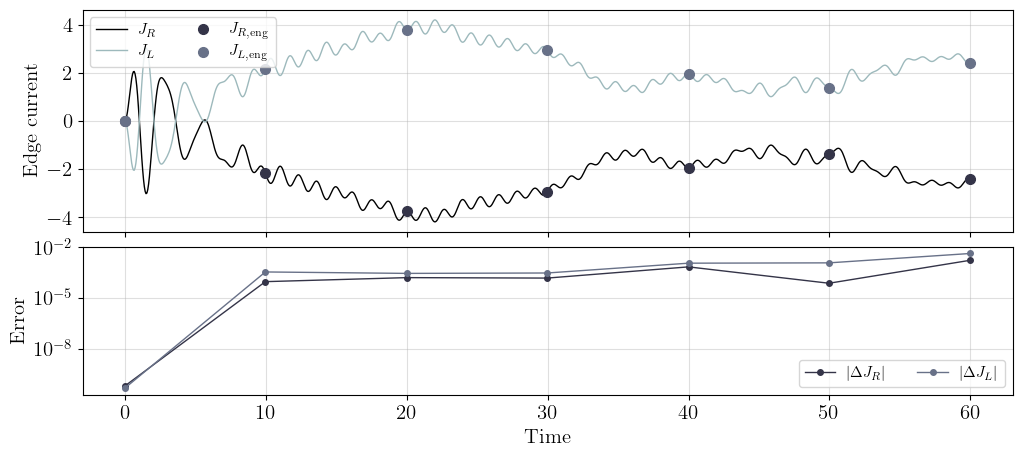

In [15]:
cmap = plt.cm.bone
colors = cmap(np.linspace(0, .7, 4))

Right, Left = np.asarray(Right), np.asarray(Left)
Right_eng, Left_eng = np.asarray(Right_eng), np.asarray(Left_eng)
scale = max(np.max(np.abs(Right)), np.max(np.abs(Left)))          # common peak scale
err_R = np.abs(Right_eng - Right[matching_indices]) / scale
err_L = np.abs(Left_eng  - Left[matching_indices])  / scale

fig, (ax, axe) = plt.subplots(
    2, 1, figsize=(12, 5), sharex=True,
    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.08})

ax.grid(alpha=0.4)
ax.plot(time_steps_exact, Right, '-', label=r'$J_R$', color=colors[0], lw=1)
ax.plot(time_steps_exact, Left,  '-', label=r'$J_L$', color=colors[3], lw=1)
ax.plot(time_steps_eng, Right_eng, 'o', label=r'$J_{R,\mathrm{eng}}$', color=colors[1], ms=7)
ax.plot(time_steps_eng, Left_eng,  'o', label=r'$J_{L,\mathrm{eng}}$', color=colors[2], ms=7)
ax.set_ylabel('Edge current')
ax.legend(loc='upper left', ncol=2, fontsize=11)

axe.grid(alpha=0.4, which='both')
axe.semilogy(time_steps_eng, err_R, 'o-', color=colors[1], ms=4, lw=1, label=r'$|\Delta J_R|$')
axe.semilogy(time_steps_eng, err_L, 'o-', color=colors[2], ms=4, lw=1, label=r'$|\Delta J_L|$')
axe.set_ylabel('Error')
axe.set_xlabel('Time')
axe.legend(loc='best', fontsize=11, ncol=2)

plt.show()

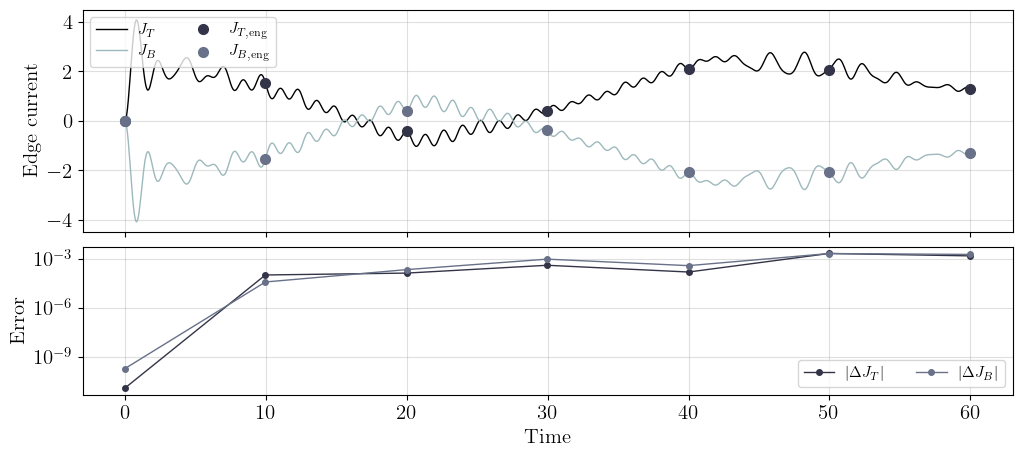

In [16]:
cmap = plt.cm.bone
colors = cmap(np.linspace(0, .7, 4))

Top, Bot = np.asarray(Top), np.asarray(Bot)
Top_eng, Bot_eng = np.asarray(Top_eng), np.asarray(Bot_eng)
scale = max(np.max(np.abs(Top)), np.max(np.abs(Bot)))          # common peak scale
err_T = np.abs(Top_eng - Top[matching_indices]) / scale
err_B = np.abs(Bot_eng  - Bot[matching_indices])  / scale

fig, (ax, axe) = plt.subplots(
    2, 1, figsize=(12, 5), sharex=True,
    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.08})

ax.grid(alpha=0.4)
ax.plot(time_steps_exact, Top, '-', label=r'$J_T$', color=colors[0], lw=1)
ax.plot(time_steps_exact, Bot,  '-', label=r'$J_B$', color=colors[3], lw=1)
ax.plot(time_steps_eng, Top_eng, 'o', label=r'$J_{T,\mathrm{eng}}$', color=colors[1], ms=7)
ax.plot(time_steps_eng, Bot_eng,  'o', label=r'$J_{B,\mathrm{eng}}$', color=colors[2], ms=7)
ax.set_ylabel('Edge current')
ax.legend(loc='upper left', ncol=2, fontsize=11)

axe.grid(alpha=0.4, which='both')
axe.semilogy(time_steps_eng, err_T, 'o-', color=colors[1], ms=4, lw=1, label=r'$|\Delta J_T|$')
axe.semilogy(time_steps_eng, err_B, 'o-', color=colors[2], ms=4, lw=1, label=r'$|\Delta J_B|$')
axe.set_ylabel('Error')
axe.set_xlabel('Time')
axe.legend(loc='best', fontsize=11, ncol=2)

plt.show()

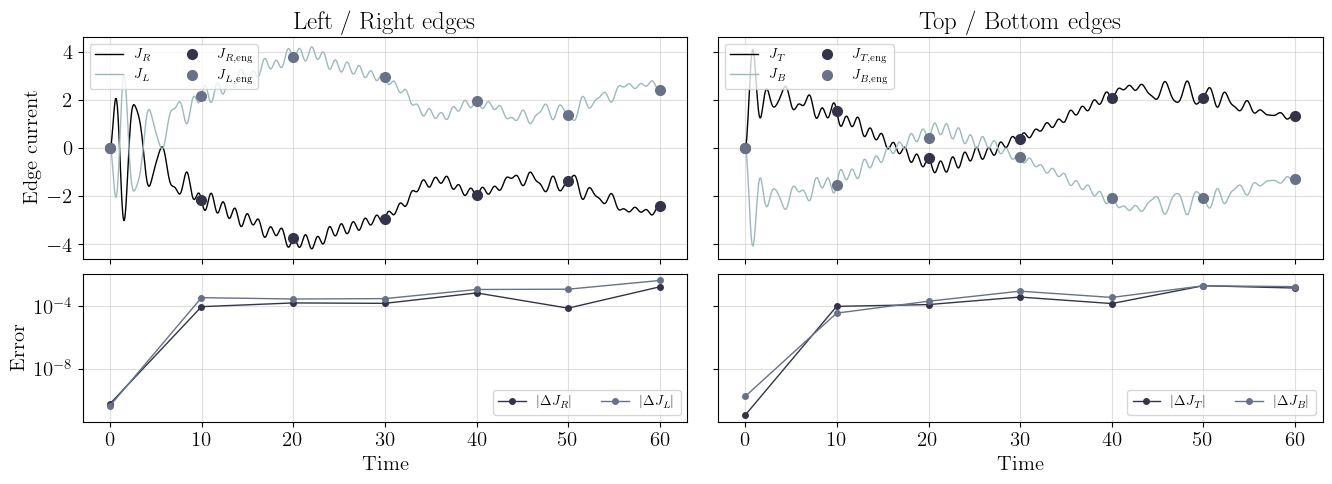

In [19]:

cmap = plt.cm.bone
colors = cmap(np.linspace(0, .7, 4))

Right, Left = np.asarray(Right), np.asarray(Left)
Right_eng, Left_eng = np.asarray(Right_eng), np.asarray(Left_eng)
Top, Bot = np.asarray(Top), np.asarray(Bot)
Top_eng, Bot_eng = np.asarray(Top_eng), np.asarray(Bot_eng)

# single common scale across ALL four edges -> errors are comparable on a shared axis
scale = max(np.max(np.abs(a)) for a in (Right, Left, Top, Bot))
err_R = np.abs(Right_eng - Right[matching_indices]) / scale
err_L = np.abs(Left_eng  - Left[matching_indices])  / scale
err_T = np.abs(Top_eng   - Top[matching_indices])   / scale
err_B = np.abs(Bot_eng   - Bot[matching_indices])   / scale

fig, axes = plt.subplots(
    2, 2, figsize=(16, 5), sharex=True, sharey='row',
    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.08, 'wspace': 0.05})
(curRL, curTB), (errRL, errTB) = axes

# --- top-left: Left / Right currents ---
curRL.grid(alpha=0.4)
curRL.plot(time_steps_exact, Right, '-', color=colors[0], lw=1, label=r'$J_R$')
curRL.plot(time_steps_exact, Left,  '-', color=colors[3], lw=1, label=r'$J_L$')
curRL.plot(time_steps_eng, Right_eng, 'o', color=colors[1], ms=7, label=r'$J_{R,\mathrm{eng}}$')
curRL.plot(time_steps_eng, Left_eng,  'o', color=colors[2], ms=7, label=r'$J_{L,\mathrm{eng}}$')
curRL.set_ylabel('Edge current')
curRL.set_title('Left / Right edges')
curRL.legend(loc='upper left', ncol=2, fontsize=10)

# --- top-right: Top / Bottom currents ---
curTB.grid(alpha=0.4)
curTB.plot(time_steps_exact, Top, '-', color=colors[0], lw=1, label=r'$J_T$')
curTB.plot(time_steps_exact, Bot, '-', color=colors[3], lw=1, label=r'$J_B$')
curTB.plot(time_steps_eng, Top_eng, 'o', color=colors[1], ms=7, label=r'$J_{T,\mathrm{eng}}$')
curTB.plot(time_steps_eng, Bot_eng, 'o', color=colors[2], ms=7, label=r'$J_{B,\mathrm{eng}}$')
curTB.set_title('Top / Bottom edges')
curTB.legend(loc='upper left', ncol=2, fontsize=10)

# --- bottom-left: Left / Right error ---
errRL.grid(alpha=0.4, which='both')
errRL.semilogy(time_steps_eng, err_R, 'o-', color=colors[1], ms=4, lw=1, label=r'$|\Delta J_R|$')
errRL.semilogy(time_steps_eng, err_L, 'o-', color=colors[2], ms=4, lw=1, label=r'$|\Delta J_L|$')
errRL.set_ylabel('Error')
errRL.set_xlabel('Time')
errRL.legend(loc='lower right', ncol=2, fontsize=10)

# --- bottom-right: Top / Bottom error ---
errTB.grid(alpha=0.4, which='both')
errTB.semilogy(time_steps_eng, err_T, 'o-', color=colors[1], ms=4, lw=1, label=r'$|\Delta J_T|$')
errTB.semilogy(time_steps_eng, err_B, 'o-', color=colors[2], ms=4, lw=1, label=r'$|\Delta J_B|$')
errTB.set_xlabel('Time')
errTB.legend(loc='lower right', ncol=2, fontsize=10)

plt.savefig("edge_currents.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()